# Monte Carlo simulace dle Guillochonova článku

Tento notebook ukazuje MC simulaci TDE podle článku Guillochon et al. (2015). Veškeré funkcionality jsem modularizoval do balíčku TDESim, kde jsou stručná vysvětlení v docstrings jednotlivých funkcí. Podrobnější popis výpočtů a odvození je provizorně sepsaný v overleafu.

Nejprve importuji všechny potřebné závislosti:

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import TDESim as tde
from TDESim.config import SimulationParams
from TDESim.utils import rsun_to_rg

Vytvoříme generátor náhodných čísel a zadáme společné parametry simulace:

In [3]:
rng = np.random.default_rng(42) # seed 42 pro reprodukovatelnost
Nsim = 1000 # počet běhů simulace
res = 1000 # úhlové rozlišení simulace
e = 0.999 # velká excentricita, pro jednoduchost společná

Začneme generováním hmotností a spinů černé díry:

In [4]:
Mh = 10**rng.uniform(5,8,Nsim)
a = rng.uniform(0,1,Nsim)

Parametry hvězdy generujeme dle článků předepsaných v Guillochonovi:

In [5]:
# (13) from Kroupa, P., Tout, C. A., and Gilmore, G., 
# “The Distribution of Low-Mass Stars in the Galactic Disc”

Mstar = tde.kroupa(0.1,100,Nsim,rng)

# (2) from Tout, C. A., Pols, O. R., Eggleton, P. P., and Han, Z., 
# “Zero-age main-seqence radii and luminosities as analytic functions of mass and metallicity”

Rstar = tde.tout_get_radius(Mstar)

Parametry orbity musíme generovat tak, aby byly nad IBCO - pokud nejsou, musíme znovu vylosovat inklinaci a beta.

In [6]:
i = np.empty_like(a)
beta = np.empty_like(a)

for n in range(Nsim):
    check = True
    while check:
        i_sample = rng.uniform(0, np.pi)
        beta_sample = rng.pareto(1)
        if tde.check_IBCO(beta_sample, i_sample, a[n], Mh[n], Rstar[n], Mstar[n]):
            continue
        if abs(i_sample - np.pi/2) <= 1e-10:
            continue
        check = False
    i[n] = i_sample
    beta[n] = beta_sample

Nyní spustíme samotnou *simulaci*:

In [7]:
rp = rsun_to_rg(Rstar, Mh) * (Mh/Mstar)**(1/3) / beta

windings = np.empty_like(a)
incident = np.empty_like(a)

for n in range(Nsim):
    params = SimulationParams(Rstar[n], Mstar[n], Mh[n], rp[n], a[n], e, i[n], res)
    
    omega_apsidal, omega_nodal = tde.pn.precession(params)
    init_ell = tde.pn.init_ellipse(params) # Kód jsem napsal tak, že se jednou vygeneruje základní PN elipsa a potom se jen správně orientuje v prostoru
    
    intersection = False
    k = 0
    zeroth_ellipse = tde.pn.evolve_orbit(params, init_ell, 0, 0).T
    trajectory = [zeroth_ellipse]
    
    while intersection == False:
        k += 1
        ellipse = tde.pn.evolve_orbit(params, init_ell, k*omega_apsidal, k*omega_nodal).T
        trajectory.append(ellipse)
        
        for l in range(k):
            test = tde.criteria.check_intersection(params, ellipse, trajectory[l], k, l)
            intersection = test["test"]
            if intersection == True: break
        
    windings[n] = k
    incident[n]= l

Nakonec vytvoříme graf, který lze srovnat s Guillochonovým výsledkem

[Text(0.5, 0, 'Počet oběhů před protnutím ($=W_1$)'),
 Text(0, 0.5, 'S kolikátou elipsou se protnul ($=W_2$)'),
 (0.5, 19.5),
 (0.5, 19.5),

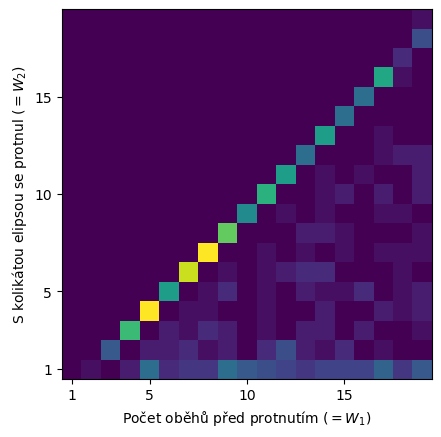

In [23]:
heatmap_matrix, x_edges, y_edges = np.histogram2d(windings[np.where(windings <= 20)]+1, incident[np.where(windings <= 20)]+1, bins = [np.arange(21), np.arange(21)])
fig, ax = plt.subplots()
ax.imshow(heatmap_matrix.T, cmap = "viridis", origin = "lower")
ax.set(xlabel=r"Počet oběhů před protnutím ($=W_1$)", ylabel=r"S kolikátou elipsou se protnul ($=W_2$)", xlim=[0.5,19.5], ylim=[0.5,19.5], xticks=[1,5,10,15], yticks=[1,5,10,15])

Zdá se, že výsledná heatmapa (zvolil jsem cmap viridis, kde tmavě fialová jsou nejnižší hodnoty a žlutá nejvyšší) vykazuje zajímavé shody i odlišnosti oproti té z článku. Zde pro srovnání přikládám kopii obrázku z Guillochon et al. (2015):

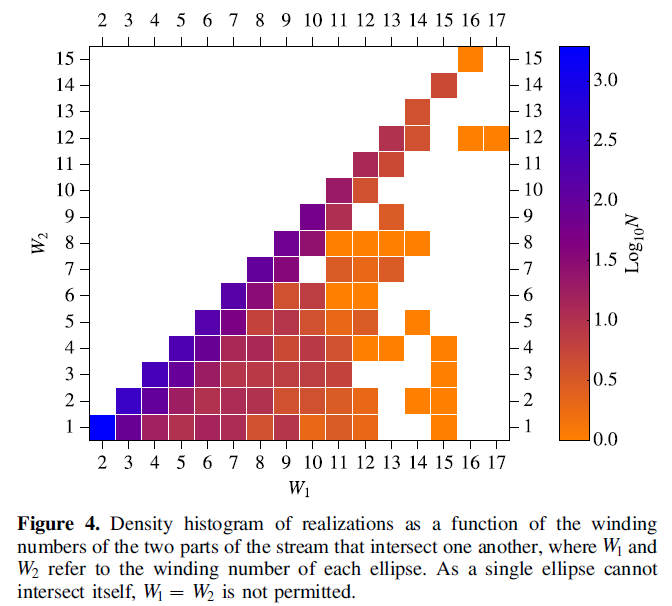

Konkrténě můžeme vidět, že nejvíce protnutí se u Guillochona objevuje hned mezi orbitami 1-2 (v naší simulaci je to ekvivalentní 0-1). Naše simulace také ukazuje "anomálii" ve smyslu zvýšeného množství protnutí s nultou orbitou (to jsou bloky podél osy x). Celkově se zdá, že pokud od těchto anomálií odhlédneme, je správně nejvyšší počet protnutí na "diagonále", stejně jako u Guillochona - to odpovídá protnutí dvou sousedních elips.

Pozn.: Graf jsem musel oříznout, protože se objevuje několik anomálních případů, kdy se proud protne až po stovkách orbit (maximum je ~ 600 orbit). Do této oblasti se dokonce vejde jen přibližně polovina eventů... Jelikož ale na tak rozsáhlé ploše heatmapy není vidět žádný detail výskytu protnutí, rozhodl jsem se jí nezahrnout (jednotlivé body na 600x600 px obrázu jsou moc malé). Pro úplnost ale naopak přikládám histogram rozdělení počtu protnutí:

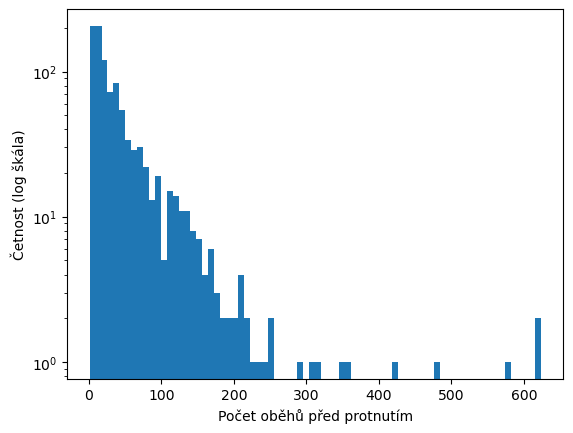

In [10]:
plot = plt.hist(windings, bins = "auto")
plt.yscale("log")
plt.xlabel("Počet oběhů před protnutím")
plt.ylabel("Četnost (log škála)")
plt.show()